```{note}
This page was generated from a Jupyter notebook.  [Download the notebook](fourcv_alignment_howto.ipynb) to run it locally — it requires only `ad_hoc_diffractometer`, NumPy, and Matplotlib.
```

# Align a Four-Circle Diffractometer (`fourcv`)

This notebook is a **how-to guide** for aligning a crystal on a four-circle
Eulerian diffractometer in the **vertical scattering plane**
([`ahd.make_geometry("fourcv")`](../geometries/fourcv.md)),
the synchrotron convention where ω and 2θ rotate about the transverse axis.

The example uses **sapphire (α-Al₂O₃)** with the (001) axis pre-aligned
along the φ-axis — a common starting configuration at synchrotron beamlines.
The motor-angle values are drawn from a real alignment session at APS
7-ID-C (December 2020, private communication, D.A. Walko).

## Alignment steps

1. Create the geometry and set the wavelength
2. Set the sample lattice constants
3. Predict Bragg peak positions
4. Enter the primary orienting reflection (calculated position)
5. Enter the secondary orienting reflection (geometric placeholder)
6. Compute the orientation matrix
7. Verify the orientation — direction check
8. Scan to find the peak; update the primary reflection with the measured position
9. Re-compute and display the refined orientation

---

## Before you begin

This guide uses `ahd.make_geometry("fourcv")` — the synchrotron four-circle with ω and 2θ
both rotating about the transverse axis (vertical scattering plane).
Users familiar with SPEC will recognize the workflow: the steps parallel
SPEC's `setor0`/`setor0`, `pa`, `ca`, and `wh` commands,
but everything runs in pure Python with no hardware connection.

---

## References

- W.R. Busing & H.A. Levy, *Acta Cryst.* **22**, 457–464 (1967)
- D.A. Walko, *Ref. Module Mater. Sci. Mater. Eng.* (2016)
- D.A. Walko, private communication (December 2020) —
  APS 7-ID-C sapphire alignment session


## Step 0 — Imports

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

import ad_hoc_diffractometer as ahd

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 4)

---

## Step 1 — Create the geometry and set the wavelength

`ahd.make_geometry("fourcv")` creates a four-circle Eulerian diffractometer in the
**vertical scattering plane** (synchrotron convention).  ω and 2θ both
rotate about the **transverse** axis (−x in the Busing & Levy coordinate
system), so the scattering plane is vertical.

The four stages and their rotation axes in the BL1967 basis
(transverse = +x, longitudinal = +y, vertical = +z):

| Stage | Axis | Handedness | Role |
|-------|------|------------|------|
| `omega` | transverse | left-handed (−x) | sample |
| `chi` | longitudinal | right-handed (+y) | sample |
| `phi` | transverse | left-handed (−x) | sample |
| `ttheta` | transverse | left-handed (−x) | detector |

In [2]:
import ad_hoc_diffractometer.axes as ahd_axes

g = ahd.make_geometry("fourcv")

# Wavelength from the beamline monochromator at APS 7-ID-C
g.wavelength = 1.5498  # Angstroms

print(f"Geometry  : {g.name}")
print(f"Wavelength: {g.wavelength} Å")
print(f"Description: {g.description}")
print()
print("Sample stages:")
for s in g.sample_stages:
    print(f"  {s.name:8s}  axis = {ahd_axes.axis_label(s.axis)}")
print("Detector stages:")
for s in g.detector_stages:
    print(f"  {s.name:8s}  axis = {ahd_axes.axis_label(s.axis)}")

Geometry  : fourcv
Wavelength: 1.5498 Å
Description: Busing & Levy (1967) four-circle Eulerian diffractometer (vertical scattering plane, transverse ttheta, synchrotron)

Sample stages:
  omega     axis = -x
  chi       axis = +y
  phi       axis = -x
Detector stages:
  ttheta    axis = -x


---

## Step 2 — Set the sample lattice constants

Sapphire (α-Al₂O₃) is trigonal / hexagonal:

| Parameter | Value |
|-----------|-------|
| a = b | 4.785 Å |
| c | 12.991 Å |
| α = β | 90° |
| γ | 120° |

`ahd.Lattice` deduces the crystal system automatically.
Supplying `a`, `c`, and `gamma=120` is sufficient for a hexagonal lattice.

In [3]:
# Hexagonal lattice: a, c, and gamma=120 are sufficient.
# ahd.Lattice deduces the crystal system automatically.
g.sample.lattice = ahd.Lattice(a=4.785, c=12.991, gamma=120.0)

print(g.sample.lattice)
print()
print("B matrix (reciprocal lattice, Å⁻¹, BL1967 convention with 2π):")
print(np.round(g.sample.lattice.B, 6))
print()
print("Reciprocal lattice parameters (a*, b*, c* = norms of the columns of B):")
b1, b2, b3 = g.sample.lattice.reciprocal_lattice_vectors
print(f"  a* = {np.linalg.norm(b1):.6f} Å⁻¹  (SPEC #G1: 1.516238 Å⁻¹)")
print(f"  b* = {np.linalg.norm(b2):.6f} Å⁻¹")
print(f"  c* = {np.linalg.norm(b3):.6f} Å⁻¹  (SPEC #G1: 0.483657 Å⁻¹)")

Lattice(hexagonal: a=4.785000 Å, c=12.991000 Å)

B matrix (reciprocal lattice, Å⁻¹, BL1967 convention with 2π):
[[ 1.3131    0.        0.      ]
 [ 0.758119  1.516238 -0.      ]
 [-0.       -0.        0.483657]]

Reciprocal lattice parameters (a*, b*, c* = norms of the columns of B):
  a* = 1.516238 Å⁻¹  (SPEC #G1: 1.516238 Å⁻¹)
  b* = 1.516238 Å⁻¹
  c* = 0.483657 Å⁻¹  (SPEC #G1: 0.483657 Å⁻¹)


The reciprocal lattice parameters include the 2π factor
(a* = 1.516 Å⁻¹, c* = 0.484 Å⁻¹), consistent with the
Busing & Levy (1967) and SPEC `pa` convention.

---

## Step 3 — Predict Bragg peak positions

Before moving any motors, use Bragg's law to predict where each reflection
should appear:

```{math}
d_{hkl} = \frac{2\pi}{|\mathbf{B}\,\mathbf{h}|}
\qquad
2\theta = 2\arcsin\left(\frac{\lambda}{2\,d_{hkl}}\right)
```

The **B** matrix follows the Busing & Levy (1967) and SPEC convention:
it includes the 2π factor, so `|B @ h| = 2π/d_hkl` (in Å⁻¹).
This is consistent with `UB @ hkl = Q_phi` where
`|Q_phi| = (2π/λ) · 2 sin θ`.

In [4]:
def bragg_angles(geometry, h, k, l):
    """
    Return (d_hkl in Å, 2theta in degrees) for reflection (h, k, l).

    Uses Bragg's law: λ = 2 d sin θ.
    The B matrix includes the 2π factor (BL1967 convention), so
    d = 2π / |B @ hkl|.
    Returns (d, None) if the reflection is not reachable at the current
    wavelength (sin θ > 1).
    """
    B = geometry.sample.lattice.B
    q_vec = B @ np.array([h, k, l], dtype=float)
    q_mag = np.linalg.norm(q_vec)   # = 2π/d_hkl  (Å⁻¹, BL1967)
    d = 2.0 * math.pi / q_mag
    sin_theta = geometry.wavelength / (2.0 * d)
    if sin_theta > 1.0:
        return d, None
    tth = 2.0 * math.degrees(math.asin(sin_theta))
    return d, tth


reflections_to_check = [(0, 0, 6), (1, 0, 0), (1, 0, 4), (0, 0, 12)]

print(f"{'hkl':>12s}  {'d (Å)':>8s}  {'2θ (deg)':>10s}")
print("-" * 36)
for hkl in reflections_to_check:
    d, tth = bragg_angles(g, *hkl)
    tth_str = f"{tth:10.4f}" if tth is not None else "  unreachable"
    print(f"({hkl[0]:1d} {hkl[1]:1d} {hkl[2]:2d})         {d:8.4f}  {tth_str}")

print()
_, tth_006 = bragg_angles(g, 0, 0, 6)
print(f"SPEC 'ca 0 0 6' prediction: 2θ = 41.9419°")
print(f"Our  Bragg prediction:      2θ = {tth_006:.4f}°")

         hkl     d (Å)    2θ (deg)
------------------------------------
(0 0  6)           2.1652     41.9418
(1 0  0)           4.1439     21.5551
(1 0  4)           2.5562     35.2929
(0 0 12)           1.0826     91.4156

SPEC 'ca 0 0 6' prediction: 2θ = 41.9419°
Our  Bragg prediction:      2θ = 41.9418°


With the (001) axis pre-aligned along the φ-axis, the (006) reflection
sits in the vertical scattering plane when **χ = 90°** (tilting the
c-axis into the plane).  In bisecting mode (ω = 2θ/2), the predicted
position is:

```
2θ ≈ 41.94°     ω ≈ 20.97°     χ = 90°     φ = 0°
```

---

## Step 4 — Enter the primary orienting reflection (calculated position)

The **primary orienting reflection** (or1) is entered at its *calculated*
position before any scanning.  This gives the package enough information
to compute a provisional orientation matrix.

The primary reflection is recorded at its calculated position
(equivalent to SPEC's `setor0`):

```
hkl = (0, 0, 6)
2θ = 41.9419°   ω = 20.97°   χ = 90°   φ = 0°
```

Note that χ = **+90°** is used (not the −90° that `g.forward()` may
return as its first solution).  With the c-axis nominally along the
φ-axis, χ = +90° brings c* into the vertical scattering plane without
requiring φ to move to −90°.

In [5]:
# Calculated position of (006) — χ = +90° to bring c-axis into scattering plane
or1_angles_calc = {
    "ttheta": 41.9419,
    "omega":  20.97,
    "chi":    90.0,
    "phi":    0.0,
}

g.add_reflection(
    "or1",
    hkl=(0, 0, 6),
    angles=or1_angles_calc,
    wavelength=g.wavelength,
)
g.sample.reflections.setor0("or1")

r = g.sample.reflections["or1"]
print(f"or1  hkl    : {r.hkl}")
print(f"     angles : {r.angles}")
print(f"     lambda : {r.wavelength} Å")

or1  hkl    : (0.0, 0.0, 6.0)
     angles : {'ttheta': 41.9419, 'omega': 20.97, 'chi': 90.0, 'phi': 0.0}
     lambda : 1.5498 Å


---

## Step 5 — Enter the secondary orienting reflection (geometric placeholder)

A single reflection constrains only one reciprocal-lattice direction.  A
second, non-parallel reflection is needed to fully define the crystal
orientation.

A second reflection 90° away in φ is recorded as a geometric placeholder
(equivalent to SPEC's `setor0`):

```
hkl = (1, 0, 0)
2θ = 60°   θ = 30°   χ = 0°   φ = 0°
```

> **Accommodation**: `2θ = 60°` is **not** the Bragg angle for (1, 0, 0)
> of sapphire at λ = 1.5498 Å.  The true Bragg angle is 2θ ≈ 18.64°.
> SPEC accepts this geometric placeholder because the UB algorithm uses
> only the **direction** of the scattering vector (normalized), not its
> magnitude, to build the orientation matrix.
>
> `ahd.ub_from_two_reflections_bl1967` follows the same Busing & Levy
> algorithm and therefore also accepts this placeholder.  The consequence
> is a ~7° directional misalignment for the secondary reflection in the
> direction check (Step 7) — expected and acceptable at this stage.

In [6]:
# Geometric placeholder for the secondary reflection:
# 2θ = 60° is NOT the Bragg angle for (1,0,0) of sapphire at λ = 1.5498 Å.
# The true Bragg 2θ for (1,0,0) is ~18.64°.
# This position is used only to define the φ-rotation plane direction.
or2_angles = {
    "ttheta": 60.0,
    "omega":  30.0,
    "chi":    0.0,
    "phi":    0.0,
}

_, tth_100_true = bragg_angles(g, 1, 0, 0)
print(f"True Bragg 2θ for (1,0,0) at λ={g.wavelength} Å: {tth_100_true:.4f}°")
print(f"Geometric placeholder 2θ used:                    {or2_angles['ttheta']:.4f}°")
print(f"Difference: {or2_angles['ttheta'] - tth_100_true:.4f}°  (accepted by BL1967 algorithm)")
print()

g.add_reflection(
    "or2",
    hkl=(1, 0, 0),
    angles=or2_angles,
    wavelength=g.wavelength,
)
g.sample.reflections.setor1("or2")

r = g.sample.reflections["or2"]
print(f"or2  hkl    : {r.hkl}")
print(f"     angles : {r.angles}")
print(f"     lambda : {r.wavelength} Å")

True Bragg 2θ for (1,0,0) at λ=1.5498 Å: 21.5551°
Geometric placeholder 2θ used:                    60.0000°
Difference: 38.4449°  (accepted by BL1967 algorithm)

or2  hkl    : (1.0, 0.0, 0.0)
     angles : {'ttheta': 60.0, 'omega': 30.0, 'chi': 0.0, 'phi': 0.0}
     lambda : 1.5498 Å


---

## Step 6 — Compute the orientation matrix

`ahd.ub_from_two_reflections_bl1967` computes the orientation matrix **U**
and the combined **UB** matrix using the Busing & Levy (1967) algorithm
(eqs. 23–27):

1. Compute Q_φ for each reflection from its motor angles.
2. Compute crystal-frame vectors: **h**_c = **B h**.
3. Build orthonormal triads (Gram–Schmidt) in the crystal frame (**T**_c)
   and the φ frame (**T**_φ).
4. **U** = **T**_φ **T**_c^T.
5. **UB** = **U** **B**.

In [7]:
UB_initial = ahd.ub_from_two_reflections_bl1967(g.sample)

print("UB matrix (Å⁻¹, no 2π factor):")
print(np.round(UB_initial, 6))
print()
print("U matrix (orientation):")
print(np.round(g.sample.U, 6))
print()
print(f"det(U) = {np.linalg.det(g.sample.U):.8f}  (must be +1 for a proper rotation)")
UtU = g.sample.U.T @ g.sample.U
print(f"max |U^T U - I| = {np.max(np.abs(UtU - np.eye(3))):.2e}  (must be ~0 for orthonormality)")

UB matrix (Å⁻¹, no 2π factor):
[[-0.182847  0.351047  0.45162 ]
 [ 0.06544   1.269026 -0.161633]
 [-1.503749 -0.751875 -0.061948]]

U matrix (orientation):
[[-0.272919  0.231525  0.933762]
 [-0.433381  0.836957 -0.33419 ]
 [-0.858892 -0.495882 -0.128083]]

det(U) = 1.00000000  (must be +1 for a proper rotation)
max |U^T U - I| = 3.93e-17  (must be ~0 for orthonormality)


---

## Step 7 — Verify the orientation: direction check

The orientation matrix is correct when **UB** @ **h** points in the same
**direction** as the scattering vector Q_φ computed from the measured
motor angles.  We check the cosine of the angle between the two vectors
(both normalized to unit length):

```{math}
\cos\theta = \frac{(\mathbf{UB}\,\mathbf{h}) \cdot \mathbf{Q}_\phi}
{|\mathbf{UB}\,\mathbf{h}|\;|\mathbf{Q}_\phi|}
```

cos θ = 1 means perfect alignment; θ = 0° means no angular discrepancy.

> **Expected behavior with a geometric placeholder**:  
> The primary reflection (or1) is exact by construction — cos θ = 1.  
> The secondary reflection (or2) has a ~7° discrepancy because its
> motor angles (2θ = 60°) are not at the true Bragg condition for (1,0,0).
> The orientation matrix is still valid: it correctly encodes the (006)
> direction and the φ-rotation plane.

In [8]:
def direction_check(geometry, reflection_name):
    """
    Check whether UB @ hkl is parallel to Q_phi at the recorded motor angles.

    Prints the cosine of the angle between the two directions
    (1.0 = perfectly aligned, 0° angular discrepancy).
    """
    r = geometry.sample.reflections[reflection_name]
    Q_phi = ahd.orientation.angles_to_phi_vector(geometry, **r.angles)
    UB_hkl = geometry.sample.UB @ np.array(r.hkl, dtype=float)

    Q_hat   = Q_phi   / np.linalg.norm(Q_phi)
    UBh_hat = UB_hkl  / np.linalg.norm(UB_hkl)
    cos_ang = float(np.dot(Q_hat, UBh_hat))
    angle   = math.degrees(math.acos(np.clip(cos_ang, -1.0, 1.0)))

    print(f"  {reflection_name}  hkl={r.hkl}")
    print(f"    cos(angle) = {cos_ang:.8f}   angular discrepancy = {angle:.4f}°")


print("Direction check — UB @ hkl vs Q_phi at recorded motor angles:")
print()
direction_check(g, "or1")
print()
direction_check(g, "or2")
print()
print("or1 is exact by construction.")
print("or2 has a ~7° discrepancy because 2θ=60° is not the Bragg angle")
print("for (1,0,0) of sapphire.  This is expected for a geometric placeholder.")

Direction check — UB @ hkl vs Q_phi at recorded motor angles:

  or1  hkl=(0.0, 0.0, 6.0)
    cos(angle) = 1.00000000   angular discrepancy = 0.0000°

  or2  hkl=(1.0, 0.0, 0.0)
    cos(angle) = 0.99176346   angular discrepancy = 7.3588°

or1 is exact by construction.
or2 has a ~7° discrepancy because 2θ=60° is not the Bragg angle
for (1,0,0) of sapphire.  This is expected for a geometric placeholder.


---

## Step 8 — Find the peak by scanning; update the primary reflection

At a real beamline the next steps are:

1. Move motors to the predicted (006) position.
2. Scan ω (theta) to find the peak.
3. Scan χ to center the peak.
4. Scan 2θ to confirm the peak position.
5. Enter the measured peak position as the updated primary reflection.

The data below are from the APS 7-ID-C session (private communication,
D.A. Walko, December 2020).

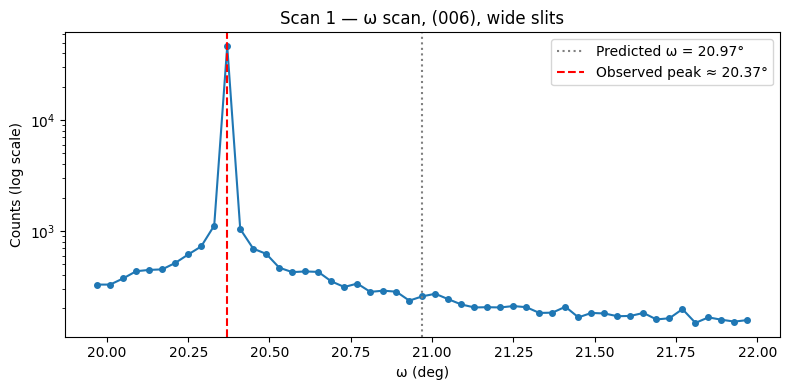

Peak found at ω ≈ 20.37°  (predicted: 20.97°)
0.6° discrepancy is consistent with χ ≠ 90° (c-axis slightly misaligned).


In [9]:
# Scan 1: ω scan, wide range, open slits — finds the peak near ω ≈ 20.37°
# (SPEC command: dscan th -1 1 50 0.1)
scan1_omega = np.linspace(19.97, 21.97, 51)
scan1_counts = np.array([
    328,   328,   373,   433,   445,   450,   514,   613,   725,  1118,
    46509, 1041,  692,   621,   466,   425,   431,   427,   351,   312,
    335,   282,   289,   283,   235,   257,   271,   242,   217,   204,
    205,   204,   210,   205,   182,   183,   207,   166,   182,   180,
    170,   171,   182,   159,   163,   197,   148,   166,   158,   152, 157,
])

peak_omega_scan1 = scan1_omega[np.argmax(scan1_counts)]

fig, ax = plt.subplots()
ax.semilogy(scan1_omega, scan1_counts, "o-", markersize=4)
ax.axvline(20.97, color="gray",  ls=":",  label=f"Predicted ω = 20.97°")
ax.axvline(peak_omega_scan1, color="red",  ls="--",
           label=f"Observed peak ≈ {peak_omega_scan1:.2f}°")
ax.set_xlabel("ω (deg)")
ax.set_ylabel("Counts (log scale)")
ax.set_title("Scan 1 — ω scan, (006), wide slits")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak found at ω ≈ {peak_omega_scan1:.2f}°  (predicted: 20.97°)")
print("0.6° discrepancy is consistent with χ ≠ 90° (c-axis slightly misaligned).")

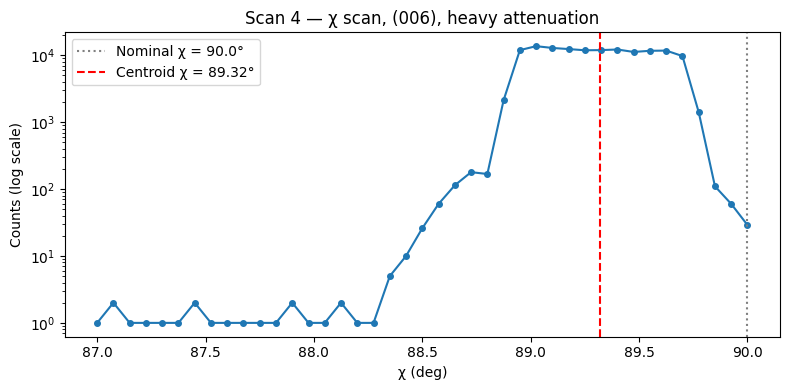

χ centroid = 89.32°  (nominal: 90.0°,  offset: -0.68°)
The c-axis is 0.68° from the φ-axis — the crystal is slightly miscut.


In [10]:
# Scan 4: χ scan, heavy attenuation — locates the true chi position
# (SPEC command: dscan chi -3 0 40 0.5)
scan4_chi = np.linspace(87.0, 90.0, 41)
scan4_counts = np.array([
     0,     2,     0,     1,     0,     0,     2,     0,     0,     1,
     0,     0,     2,     1,     1,     2,     1,     1,     5,    10,
    26,    60,   114,   179,   168,  2130, 11934, 13676, 12861, 12379,
    11871, 11947, 12192, 11207, 11665, 11745,  9734,  1411,   110,    60, 29,
])

fig, ax = plt.subplots()
ax.semilogy(scan4_chi, np.maximum(scan4_counts, 1), "o-", markersize=4)
ax.axvline(90.0, color="gray", ls=":", label="Nominal χ = 90.0°")
ax.axvline(89.32, color="red",  ls="--", label="Centroid χ = 89.32°")
ax.set_xlabel("χ (deg)")
ax.set_ylabel("Counts (log scale)")
ax.set_title("Scan 4 — χ scan, (006), heavy attenuation")
ax.legend()
plt.tight_layout()
plt.show()

chi_measured = 89.32  # SPEC centroid from the scan
print(f"χ centroid = {chi_measured}°  (nominal: 90.0°,  offset: {chi_measured - 90.0:.2f}°)")
print("The c-axis is 0.68° from the φ-axis — the crystal is slightly miscut.")

After centering in ω, χ, and 2θ, the **measured** peak position is:

```
2θ = 41.9394°     ω = 20.3654°     χ = 89.32°     φ = 0°
```

Replace the calculated primary reflection with this measured position:

In [11]:
# Measured peak position after scanning and centering
or1_angles_meas = {
    "ttheta": 41.9394,
    "omega":  20.3654,
    "chi":    89.32,
    "phi":    0.0,
}

# Remove the calculated or1 and replace with the measured position
g.sample.reflections.remove("or1")
g.add_reflection(
    "or1",
    hkl=(0, 0, 6),
    angles=or1_angles_meas,
    wavelength=g.wavelength,
)
g.sample.reflections.setor0("or1")

print("Updated or1 (measured position):")
r = g.sample.reflections["or1"]
print(f"  hkl    : {r.hkl}")
print(f"  angles : {r.angles}")

Updated or1 (measured position):
  hkl    : (0.0, 0.0, 6.0)
  angles : {'ttheta': 41.9394, 'omega': 20.3654, 'chi': 89.32, 'phi': 0.0}


---

## Step 9 — Re-compute the orientation matrix and display the state

Re-running `ub_from_two_reflections_bl1967` with the measured or1 gives a
refined **UB** matrix that reflects the actual crystal alignment.

In [12]:
UB_refined = ahd.ub_from_two_reflections_bl1967(g.sample)

print("UB matrix — initial (calculated) vs refined (measured):")
print(f"{'':30s}  {'Initial':>10s}  {'Refined':>10s}")
labels = [(i, j) for i in range(3) for j in range(3)]
for i, j in labels:
    print(f"  UB[{i},{j}]  {UB_initial[i,j]:12.6f}  {UB_refined[i,j]:12.6f}")
print()
print("Off-diagonal terms grow slightly — consistent with the 0.68° χ offset.")
print()
norm_initial = np.linalg.norm(UB_initial)
norm_refined = np.linalg.norm(UB_refined)
off_diag_initial = np.linalg.norm(UB_initial - np.diag(np.diag(UB_initial)))
off_diag_refined = np.linalg.norm(UB_refined - np.diag(np.diag(UB_refined)))
print(f"Frobenius norm:            initial = {norm_initial:.6f}  refined = {norm_refined:.6f}")
print(f"Off-diagonal Frobenius norm: initial = {off_diag_initial:.6f}  refined = {off_diag_refined:.6f}")
print("(A larger off-diagonal norm in the refined matrix reflects the measured χ offset.)")

UB matrix — initial (calculated) vs refined (measured):
                                   Initial     Refined
  UB[0,0]     -0.182847     -0.192788
  UB[0,1]      0.351047      0.343112
  UB[0,2]      0.451620      0.451592
  UB[1,0]      0.065440      0.068477
  UB[1,1]      1.269026      1.271602
  UB[1,2]     -0.161633     -0.160404
  UB[2,0]     -1.503749     -1.502372
  UB[2,1]     -0.751875     -0.751186
  UB[2,2]     -0.061948     -0.065261

Off-diagonal terms grow slightly — consistent with the 0.68° χ offset.

Frobenius norm:            initial = 2.198153  refined = 2.198153
Off-diagonal Frobenius norm: initial = 1.784427  refined = 1.781427
(A larger off-diagonal norm in the refined matrix reflects the measured χ offset.)


In [13]:
# Direction check after refinement
print("Direction check after entering the measured or1:")
print()
direction_check(g, "or1")
print()
direction_check(g, "or2")
print()
print("or1 remains exact.")
print("or2 still shows ~7° discrepancy — the geometric placeholder has not changed.")

Direction check after entering the measured or1:

  or1  hkl=(0.0, 0.0, 6.0)
    cos(angle) = 1.00000000   angular discrepancy = 0.0000°

  or2  hkl=(1.0, 0.0, 0.0)
    cos(angle) = 0.99085492   angular discrepancy = 7.7547°

or1 remains exact.
or2 still shows ~7° discrepancy — the geometric placeholder has not changed.


In [14]:
# Set the azimuthal reference to the c-axis (conventional for surface work)
g.azimuthal_reference = (0, 0, 1)

# pa() prints the full SPEC-style diffractometer status
g.pa(print=True)

Geometry: fourcv

  Primary Reflection (at lambda 1.5498):
    ttheta  omega  chi  phi = 41.9394  20.3654  89.32  0
    H K L = 0  0  6

  Secondary Reflection (at lambda 1.5498):
    ttheta  omega  chi  phi = 60  30  0  0
    H K L = 1  0  0

  Lattice Constants (lengths / angles):
      real space = 4.785 4.785 12.991 / 90 90 120
    reciprocal space = 1.516 1.516 0.4837 / 90 90 60

  Azimuthal Reference:  H K L = 0  0  1

  Lambda = 1.5498


'Geometry: fourcv\n\n  Primary Reflection (at lambda 1.5498):\n    ttheta  omega  chi  phi = 41.9394  20.3654  89.32  0\n    H K L = 0  0  6\n\n  Secondary Reflection (at lambda 1.5498):\n    ttheta  omega  chi  phi = 60  30  0  0\n    H K L = 1  0  0\n\n  Lattice Constants (lengths / angles):\n      real space = 4.785 4.785 12.991 / 90 90 120\n    reciprocal space = 1.516 1.516 0.4837 / 90 90 60\n\n  Azimuthal Reference:  H K L = 0  0  1\n\n  Lambda = 1.5498'

In [15]:
# Set motors to the measured (006) position and display wh()
for name, val in or1_angles_meas.items():
    g.set_angle(name, val)

g.wh(print=True)

H K L =   0  0  5.99967
Psi = not available
Lambda = 1.5498

     Theta       Chi       Phi  TwoTheta
    20.365    89.320     0.000    41.939


'H K L =   0  0  5.99967\nPsi = not available\nLambda = 1.5498\n\n     Theta       Chi       Phi  TwoTheta\n    20.365    89.320     0.000    41.939'

---

## Summary

The alignment procedure in `ad_hoc_diffractometer` follows the same steps
as a typical SPEC workflow.  The table below compares the calculated and
measured (006) peak positions.

In [16]:
_, tth_calc = bragg_angles(g, 0, 0, 6)
omega_calc  = tth_calc / 2.0
chi_calc    = 90.0

rows = [
    ("2θ (deg)",  tth_calc,    or1_angles_meas["ttheta"]),
    ("ω (deg)",   omega_calc,  or1_angles_meas["omega"]),
    ("χ (deg)",   chi_calc,    or1_angles_meas["chi"]),
    ("φ (deg)",   0.0,         or1_angles_meas["phi"]),
]

print(f"(006) reflection — calculated vs measured:")
print(f"  {'':10s}  {'Calculated':>12s}  {'Measured':>12s}  {'Δ':>8s}")
print("-" * 52)
for label, calc, meas in rows:
    delta = meas - calc
    print(f"  {label:10s}  {calc:12.4f}  {meas:12.4f}  {delta:+8.4f}")

print()
print("The 0.68° offset in χ (c-axis tilt) causes the ~0.61° shift in ω.")

(006) reflection — calculated vs measured:
                Calculated      Measured         Δ
----------------------------------------------------
  2θ (deg)         41.9418       41.9394   -0.0024
  ω (deg)          20.9709       20.3654   -0.6055
  χ (deg)          90.0000       89.3200   -0.6800
  φ (deg)           0.0000        0.0000   +0.0000

The 0.68° offset in χ (c-axis tilt) causes the ~0.61° shift in ω.


---

## What next?

With the orientation matrix established, the diffractometer can:

- **Predict other reflection positions** using `bragg_angles()` above.
- **Refine lattice constants** from several measured 2θ values with
  `ahd.refine_lattice_bl1967()` or `ahd.refine_lattice_simplex()`.
- **Compute the azimuthal angle ψ** with `g.psi()` once the UB matrix
  is fully refined (requires `g.azimuthal_reference` to be set).
- **Save and restore the alignment** with `g.to_dict()` / `g.from_dict()`,
  which serialises the full state (lattice, reflections, UB matrix,
  wavelength, modes, cut-points) to a JSON-compatible dict.

In [17]:
# Predict positions of additional sapphire reflections now that the
# lattice constants are confirmed
more_reflections = [
    (1, 0, 4), (0, 1, 2), (1, 1, 0), (2, 0, 0), (0, 0, 12), (1, 0, 10),
]

print(f"{'hkl':>14s}  {'d (Å)':>8s}  {'2θ (deg)':>10s}")
print("-" * 38)
for hkl in more_reflections:
    d, tth = bragg_angles(g, *hkl)
    if tth is not None:
        print(f"({hkl[0]:1d} {hkl[1]:1d} {hkl[2]:2d})           {d:8.4f}  {tth:10.4f}")
    else:
        print(f"({hkl[0]:1d} {hkl[1]:1d} {hkl[2]:2d})           {d:8.4f}  unreachable")

           hkl     d (Å)    2θ (deg)
--------------------------------------
(1 0  4)             2.5562     35.2929
(0 1  2)             3.4935     25.6307
(1 1  0)             2.3925     37.7963
(2 0  0)             2.0720     43.9241
(0 0 12)             1.0826     91.4156
(1 0 10)             1.2396     77.3811


In [18]:
import json

state = g.to_dict()
print("Keys in saved alignment state:")
print([k for k in state if not k.startswith("_")])
print()
print(f"JSON-serialisable: {bool(json.dumps(state))}")
print()
print("The saved state can be restored later with:")
print("  g2 = ahd.AdHocDiffractometer.from_dict(state)")

Keys in saved alignment state:
['name', 'description', 'wavelength', 'kappa_alpha_deg', 'azimuthal_reference', 'surface_normal', 'detector_distance', 'detector_tilt', 'detector_offset', 'inclination_matrix', 'basis', 'stages', 'active_sample', 'samples', 'modes', 'mode_name', 'cut_points']

JSON-serialisable: True

The saved state can be restored later with:
  g2 = ahd.AdHocDiffractometer.from_dict(state)
